In [1]:
import numpy as np
import timeit
import pandas as pd
from typing import NamedTuple, List, Tuple
from IPython.display import display
from shapely.geometry import Point, Polygon
from shapely.geometry.polygon import Polygon as ShapelyPolygon
import pickle
import sys
# Add measurement mcts python package to path
sys.path.append('../src/measurement_mcts')
from measurement_mcts.environment.measurement_control_env import MeasurementControlEnvironment
from measurement_mcts.utils.utils import get_ellipse_scaling
from measurement_mcts.environment.object_manager import ObjectManager, ObjectTuple
from measurement_mcts.environment.static_kf_2d import measurement_model

/home/austin/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [10]:
env = MeasurementControlEnvironment(init_reset=False)
car_state = env.car.reset()
env.object_manager.reset(car_state)

Toy Measurement Control Initialized


In [16]:
def get_noisy_observation(car_state):
    """
    Get a noisy observation containing the observable ooi corners.
    Noise is modelled by range-bearing sensor model with Gaussian noise.
    
    returns:
    - observation_indices: Dictionary of observed OOI corners for displaying observation arrows
    - noisy_observation: Dictionary of noisy OOI corner positions
    """
    
    # Get the observation indices
    observation_indices = env.object_manager.get_observation_indices(car_state)
    
    # Create the noisy observation
    noisy_observation = {}
    for ooi_idx, observed_corners in observation_indices.items():
        # Create a noisy corner for each observed corner
        noisy_corners = np.zeros((len(observed_corners), 2))
        
        # Loop through each observed corner and add noise using the measurement model
        for j, corner_idx in enumerate(observed_corners):
            # Get the corner of the OOI
            corner = env.object_manager.oois[ooi_idx][corner_idx]
            
            # Use the measurement model to get the observation matrix
            observation_matrix = measurement_model(corner, car_state[0:2], car_state[3])
            
            # Add noise to the real corner using the observation matrix
            noisy_corners[j] = np.random.multivariate_normal(corner, observation_matrix)
    
        # Add the noisy corners to the noisy observation
        noisy_observation[ooi_idx] = noisy_corners
        
    return observation_indices, noisy_observation
print('OOI corners: ')
print(env.object_manager.oois)
observation_indices, noisy_observation = get_noisy_observation(car_state)
print('noisy ooi corners: ')
print(noisy_observation)

OOI corners: 
[[[37.57952727 60.02360038]
  [45.93788424 60.02360038]
  [45.93788424 63.57734192]
  [37.57952727 63.57734192]]

 [[60.22322449 59.60257278]
  [64.74976723 59.60257278]
  [64.74976723 65.37521472]
  [60.22322449 65.37521472]]

 [[68.38037667 77.73373661]
  [79.75913728 77.73373661]
  [79.75913728 82.76546176]
  [68.38037667 82.76546176]]

 [[17.40452003 79.57976691]
  [26.23728692 79.57976691]
  [26.23728692 85.92992787]
  [17.40452003 85.92992787]]]
noisy ooi corners: 
{1: array([[49.45660498, 59.37306863],
       [64.42133091, 63.91220548],
       [53.92615483, 66.33078478]]), 2: array([[63.41389142, 77.769589  ]]), 0: array([[44.59142716, 63.36630231],
       [45.77612545, 66.76422132],
       [48.001203  , 61.59657659]])}


In [25]:
def get_noisy_initial_state():
    """
    Use maintained real object means to generate noisy initial states for MCTS.
    
    Class variables init_covariance_diag, init_center_stddev, init_width_guess are used to make the guess for the initial state.
    """
    
    # Create initial output data structures
    ooi_corner_means = np.zeros((env.object_manager.num_oois, 4, 2))
    ooi_corner_covariances = np.zeros((env.object_manager.num_oois, 4, 2, 2))
    
    # Fill the diagonals of the last two dimensions with the initial covariance diagonal value
    for ooi_idx in range(env.object_manager.num_oois):
        for c_idx in range(4):
            np.fill_diagonal(ooi_corner_covariances[ooi_idx, c_idx], env.object_manager.init_covariance_diag)
    
    # Generate noisy center point for each OOI
    noisy_ooi_means = env.object_manager.oois.mean(axis=1) + \
                      np.random.normal(0, env.object_manager.init_center_stddev, size=(env.object_manager.num_oois, 2))
                      
    # Use the init_width_guess to generate the corner points of the object
    h_w = env.object_manager.init_width_guess/2 # half width
    for ooi_idx in range(env.object_manager.num_oois):
        ooi_corner_means[ooi_idx] = np.array([
                    noisy_ooi_means[ooi_idx] + np.array([-h_w, -h_w]),
                    noisy_ooi_means[ooi_idx] + np.array([ h_w, -h_w]),
                    noisy_ooi_means[ooi_idx] + np.array([ h_w,  h_w]),
                    noisy_ooi_means[ooi_idx] + np.array([-h_w,  h_w])
                ])

    # Return the object means and covariances tuple
    return ooi_corner_means, ooi_corner_covariances

get_noisy_initial_state()

Noisy initial state:
[[[40.05148715 41.04437711]
  [45.05148715 41.04437711]
  [45.05148715 46.04437711]
  [40.05148715 46.04437711]]

 [[75.39412068 46.63638424]
  [80.39412068 46.63638424]
  [80.39412068 51.63638424]
  [75.39412068 51.63638424]]

 [[47.023335   31.29971629]
  [52.023335   31.29971629]
  [52.023335   36.29971629]
  [47.023335   36.29971629]]

 [[64.01203945 50.49771725]
  [69.01203945 50.49771725]
  [69.01203945 55.49771725]
  [64.01203945 55.49771725]]]


In [12]:
# Load the objects
with open('../state_configurations/new_format_test1.pkl', 'rb') as f:
    objects = pickle.load(f)

car_state = objects[0]
env.object_manager.obstacle_means = objects[1]
env.object_manager.obstacle_radii = objects[2]
env.object_manager.occlusion_means = objects[3]
env.object_manager.occlusion_radii = objects[4]
env.object_manager.oois = objects[5]

Elapsed time: 0.0013899369987484533
Observation indices: {1: [0, 1, 2], 2: [0], 0: [0, 1, 2]}


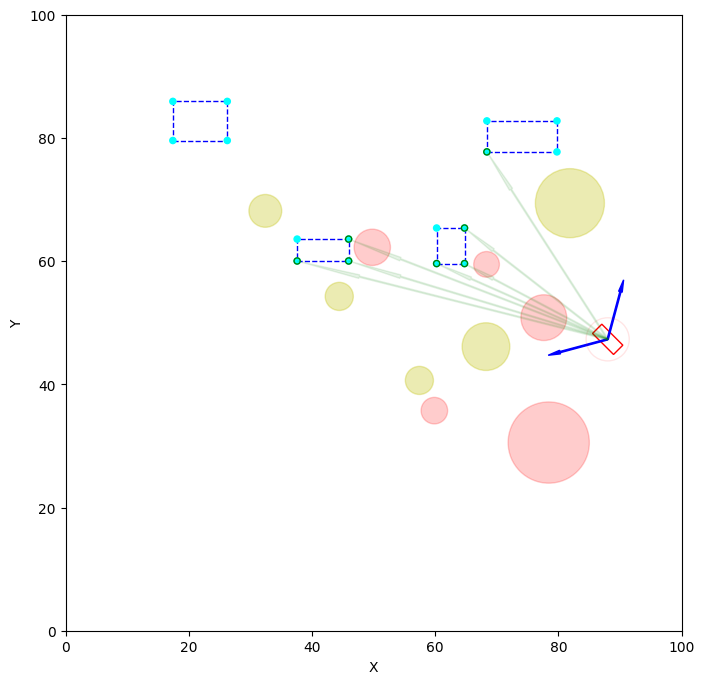

In [13]:
# car_state[0:2] = [19, 20]
# car_state[3] = np.radians(135)
env.car.draw_car_state(car_state)
start_time = timeit.default_timer()
in_collision_obs, in_collision_ocl, in_collision_oois = env.object_manager.check_collision(car_state)
observation_indices = env.object_manager.get_observation_indices(car_state)
print(f'Elapsed time: {timeit.default_timer() - start_time}')
print(f'Observation indices: {observation_indices}')
env.object_manager.draw_objects(car_state, in_collision_obs, in_collision_ocl, in_collision_oois, observation_indices=observation_indices)
env.ui.plot()

In [29]:
save_objects = (car_state,
                env.object_manager.obstacle_means,
                env.object_manager.obstacle_radii,
                env.object_manager.occlusion_means,
                env.object_manager.occlusion_radii,
                env.object_manager.oois)
# pickle the objects
with open('../state_configurations/new_format_test1.pkl', 'wb') as f:
    pickle.dump(save_objects, f)